# Libraries

In [1]:
from pathlib import Path

from tqdm import tqdm

from matplotlib import pyplot as plt
import numpy as np
import seaborn as sn
import pandas as pd
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, f1_score, confusion_matrix
from sklearn.inspection import permutation_importance
import xgboost
import shap
from boruta import BorutaPy
from helper_code import *

## Settings

In [2]:
%load_ext autoreload

%autoreload 2

# Control figure size
%matplotlib inline
figsize=(14, 4)

# Random seed
SEED = 42

# Detection of Chagas Disease from the ECG: PhysioNet Challenge 2025

## Introduction

Chagas disease is a potentially life-threatening illness caused by the protozoan parasite Trypanosoma cruzi (T. cruzi). It is found mainly in endemic areas of 21 countries in Latin America, where it is mostly transmitted to humans by the feces of triatomine bugs known as "kissing bugs". The disease is also known as American trypanosomiasis.

The disease is named after the Brazilian physician Carlos Chagas, who discovered it in 1909. The disease can be acute or chronic, but the chronic form is the most common and usually develops 10 to 30 years after the initial infection. The acute phase of the disease is usually mild or asymptomatic, but the chronic phase can cause serious heart and digestive problems.

The disease is diagnosed by detecting the parasite in the blood or by serological tests. The electrocardiogram (ECG) is an important tool for diagnosing Chagas disease, as it can show changes in the heart's electrical activity that are characteristic of the disease.

The goal of this challenge is to develop algorithms that can automatically detect Chagas disease from ECG signals. The challenge is based on a dataset of ECG signals from patients with Chagas disease and healthy controls. The dataset is provided by the PhysioNet Challenge 2025.

In [3]:
train_data_folder = Path("code15_wfdb")

train_records = find_records(train_data_folder.absolute().__str__())

We can also get the record of a patient combined with the demographic information and plot the ECG signal.

In [4]:
def get_patient_data(record_id: int) -> tuple[str, int, bool, np.ndarray, float]:
    record = f"{str(train_data_folder.absolute())}{os.sep}{record_id}"
    header = load_header(record)
    signals, fields = load_signals(record)
    frequency = get_sampling_frequency(header)
    label = get_label(header)

    return record, record_id, label, signals, frequency

In [5]:
record, exam_id, label, signals, frequency = get_patient_data(record_id=train_records[1])
print(f"Record file: {record}\nExam ID: {exam_id}\nLabel: {label}")

Record file: /home/matteo/Documenti/VSCODE/ECG-Chagas/code15_wfdb/1000078
Exam ID: 1000078
Label: 0


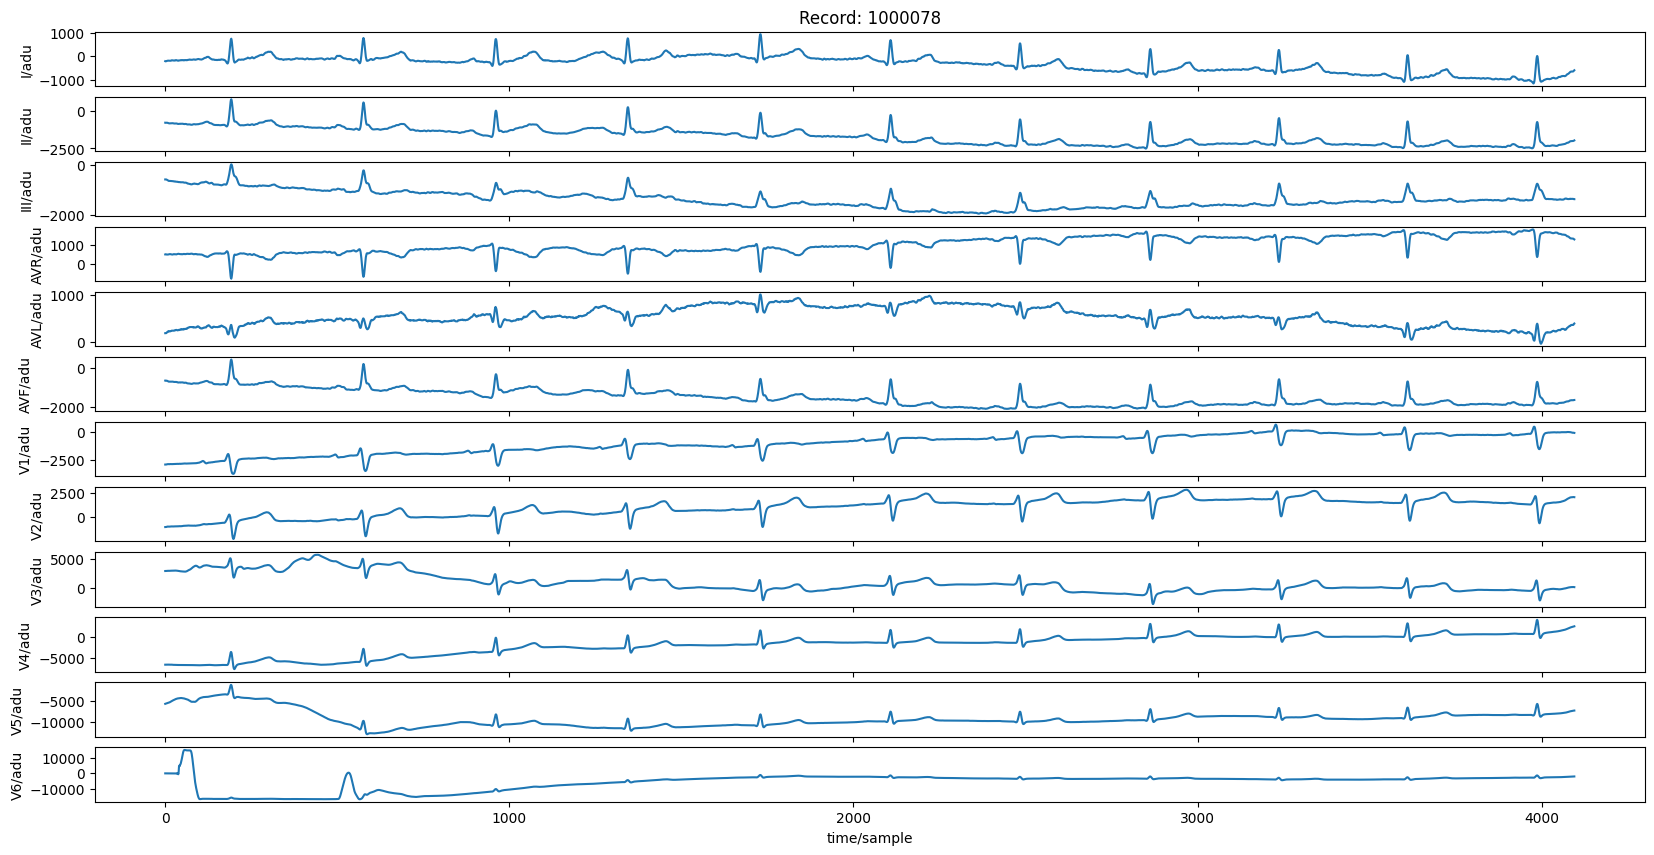

In [6]:
wfdb.plot_wfdb(record=wfdb.rdrecord(record, physical=False), figsize=(20, 10), time_units='samples')

---

## Dataset

In [27]:
data_path = Path("data")
if not (data_path / "signals_features.csv").exists():
    !python preprocessing.py --exams code15_hdf5/exams.csv --labels code15_hdf5/code15_chagas_labels.csv --train code15_wfdb/ --output data/ --seed 42 --jobs -1

In [29]:
df = pd.read_csv(data_path / "signals_features.csv")

In [30]:
to_be_dropped = df[df['ST_slope_mean'].isna()].exam_id.values.tolist()

In [31]:
df = df[~df['exam_id'].isin(to_be_dropped)].fillna(value=0)

In [32]:
df.isna().sum()

exam_id                 0
P_wave_duration_mean    0
P_wave_duration_std     0
P_wave_duration_min     0
P_wave_duration_max     0
PR_interval_mean        0
PR_interval_std         0
PR_interval_min         0
PR_interval_max         0
PR_segment_mean         0
PR_segment_std          0
PR_segment_min          0
PR_segment_max          0
QRS_duration_mean       0
QRS_duration_std        0
QRS_duration_min        0
QRS_duration_max        0
QT_interval_mean        0
QT_interval_std         0
QT_interval_min         0
QT_interval_max         0
ST_segment_mean         0
ST_segment_std          0
ST_segment_min          0
ST_segment_max          0
ST_slope_mean           0
ST_slope_std            0
ST_slope_min            0
ST_slope_max            0
HRV_MeanNN              0
HRV_SDNN                0
HRV_RMSSD               0
HRV_SDSD                0
HRV_CVNN                0
HRV_CVSD                0
HRV_MedianNN            0
HRV_MadNN               0
HRV_MCVNN               0
HRV_IQRNN   

# EDA

In [33]:
df.drop('exam_id', axis=1, inplace=True)

In [34]:
df.head()

,P_wave_duration_mean,P_wave_duration_std,P_wave_duration_min,P_wave_duration_max,PR_interval_mean,PR_interval_std,PR_interval_min,PR_interval_max,PR_segment_mean,PR_segment_std,...,HRV_Prc80NN,HRV_pNN50,HRV_pNN20,HRV_MinNN,HRV_MaxNN,HRV_HTI,HRV_TINN,age,is_male,chagas
0,36.250000,10.856203,17.5,47.5,137.812500,39.830836,110.0,222.5,101.562500,40.903578,...,1110.0,55.555556,66.666667,865.0,1135.0,4.500000,250.0000,55,False,False
1,44.285714,4.498677,37.5,52.5,87.857143,0.944911,87.5,90.0,43.571429,4.531635,...,735.0,0.000000,12.500000,710.0,740.0,2.666667,0.0000,38,False,False
2,66.590909,5.156637,60.0,75.0,86.818182,8.069302,72.5,95.0,20.227273,10.808246,...,781.0,0.000000,8.333333,735.0,792.5,6.000000,23.4375,48,False,False
3,23.333333,7.180703,15.0,40.0,146.944444,16.619726,127.5,182.5,123.611111,17.682579,...,787.0,25.000000,66.666667,640.0,822.5,4.000000,148.4375,33,False,False
4,65.000000,25.248762,35.0,92.5,128.125000,68.446299,82.5,230.0,63.125000,62.861455,...,800.0,0.000000,16.666667,737.5,805.0,3.000000,46.8750,81,False,False


In [35]:
df.describe()

,P_wave_duration_mean,P_wave_duration_std,P_wave_duration_min,P_wave_duration_max,PR_interval_mean,PR_interval_std,PR_interval_min,PR_interval_max,PR_segment_mean,PR_segment_std,...,HRV_SDRMSSD,HRV_Prc20NN,HRV_Prc80NN,HRV_pNN50,HRV_pNN20,HRV_MinNN,HRV_MaxNN,HRV_HTI,HRV_TINN,age
count,13082.000000,13082.000000,13082.000000,13082.000000,13082.000000,13082.000000,13082.000000,13082.000000,13082.000000,13082.000000,...,13082.000000,13082.000000,13082.000000,13082.000000,13082.000000,13082.000000,13082.000000,13082.000000,13082.000000,13082.000000
mean,47.571864,11.256285,34.184949,62.930936,99.432490,19.692697,75.185943,123.768728,51.860626,23.102238,...,0.902968,831.088786,912.627924,18.611972,34.804152,789.424782,957.375019,3.539173,37.598776,56.727488
std,13.670629,9.219219,15.830392,19.815176,34.775412,22.206907,40.344265,48.835064,36.539766,22.136257,...,0.301998,176.975199,194.883049,26.396604,29.467831,194.143079,240.924969,1.737762,90.700664,17.936534
min,2.500000,0.000000,0.000000,2.500000,-133.750000,0.000000,-222.500000,-132.500000,-165.000000,0.000000,...,0.000000,302.500000,330.000000,0.000000,0.000000,157.500000,332.500000,1.000000,0.000000,17.000000
25%,39.375000,4.330127,20.000000,52.500000,80.000000,5.543389,60.000000,95.000000,29.000000,8.092962,...,0.695243,717.500000,787.500000,0.000000,0.000000,667.500000,812.500000,2.333333,0.000000,43.000000
50%,47.916667,8.720187,35.000000,60.000000,94.000000,12.990381,72.500000,112.500000,44.722222,17.227038,...,0.824285,832.000000,896.500000,0.000000,33.333333,797.500000,927.500000,3.000000,0.000000,58.000000
75%,55.833333,15.990276,45.000000,72.500000,111.250000,24.706612,92.500000,137.500000,65.714286,30.845296,...,1.012095,945.000000,1013.500000,33.333333,60.000000,915.000000,1057.500000,4.333333,31.250000,72.000000
max,206.250000,120.847700,137.500000,282.500000,650.000000,274.003878,650.000000,650.000000,542.500000,272.236111,...,3.119127,2050.000000,3182.500000,94.736842,94.736842,2040.000000,4752.500000,16.000000,937.500000,94.000000


In [36]:
df.chagas.value_counts(normalize=True)

chagas
True     0.500153
False    0.499847
Name: proportion, dtype: float64

Cast the boolean columns to integers.

In [37]:
df['is_male'] = df['is_male'].astype(int)
df['chagas'] = df['chagas'].astype(int)

Exctract the numerical and categorical columns.

In [38]:
num_cols = [c for c in df.columns[:-1] if df[c].nunique() > 2]
cat_cols = [c for c in df.columns[:-1] if df[c].nunique() == 2]
print(f'Numeric: {num_cols}\nTotal: {len(num_cols)}')
print(f'Categorical: {cat_cols}\nTotal: {len(cat_cols)}')

Numeric: ['P_wave_duration_mean', 'P_wave_duration_std', 'P_wave_duration_min', 'P_wave_duration_max', 'PR_interval_mean', 'PR_interval_std', 'PR_interval_min', 'PR_interval_max', 'PR_segment_mean', 'PR_segment_std', 'PR_segment_min', 'PR_segment_max', 'QRS_duration_mean', 'QRS_duration_std', 'QRS_duration_min', 'QRS_duration_max', 'QT_interval_mean', 'QT_interval_std', 'QT_interval_min', 'QT_interval_max', 'ST_segment_mean', 'ST_segment_std', 'ST_segment_min', 'ST_segment_max', 'ST_slope_mean', 'ST_slope_std', 'ST_slope_min', 'ST_slope_max', 'HRV_MeanNN', 'HRV_SDNN', 'HRV_RMSSD', 'HRV_SDSD', 'HRV_CVNN', 'HRV_CVSD', 'HRV_MedianNN', 'HRV_MadNN', 'HRV_MCVNN', 'HRV_IQRNN', 'HRV_SDRMSSD', 'HRV_Prc20NN', 'HRV_Prc80NN', 'HRV_pNN50', 'HRV_pNN20', 'HRV_MinNN', 'HRV_MaxNN', 'HRV_HTI', 'HRV_TINN', 'age']
Total: 48
Categorical: ['is_male']
Total: 1


Plot the distribution of the numerical columns.

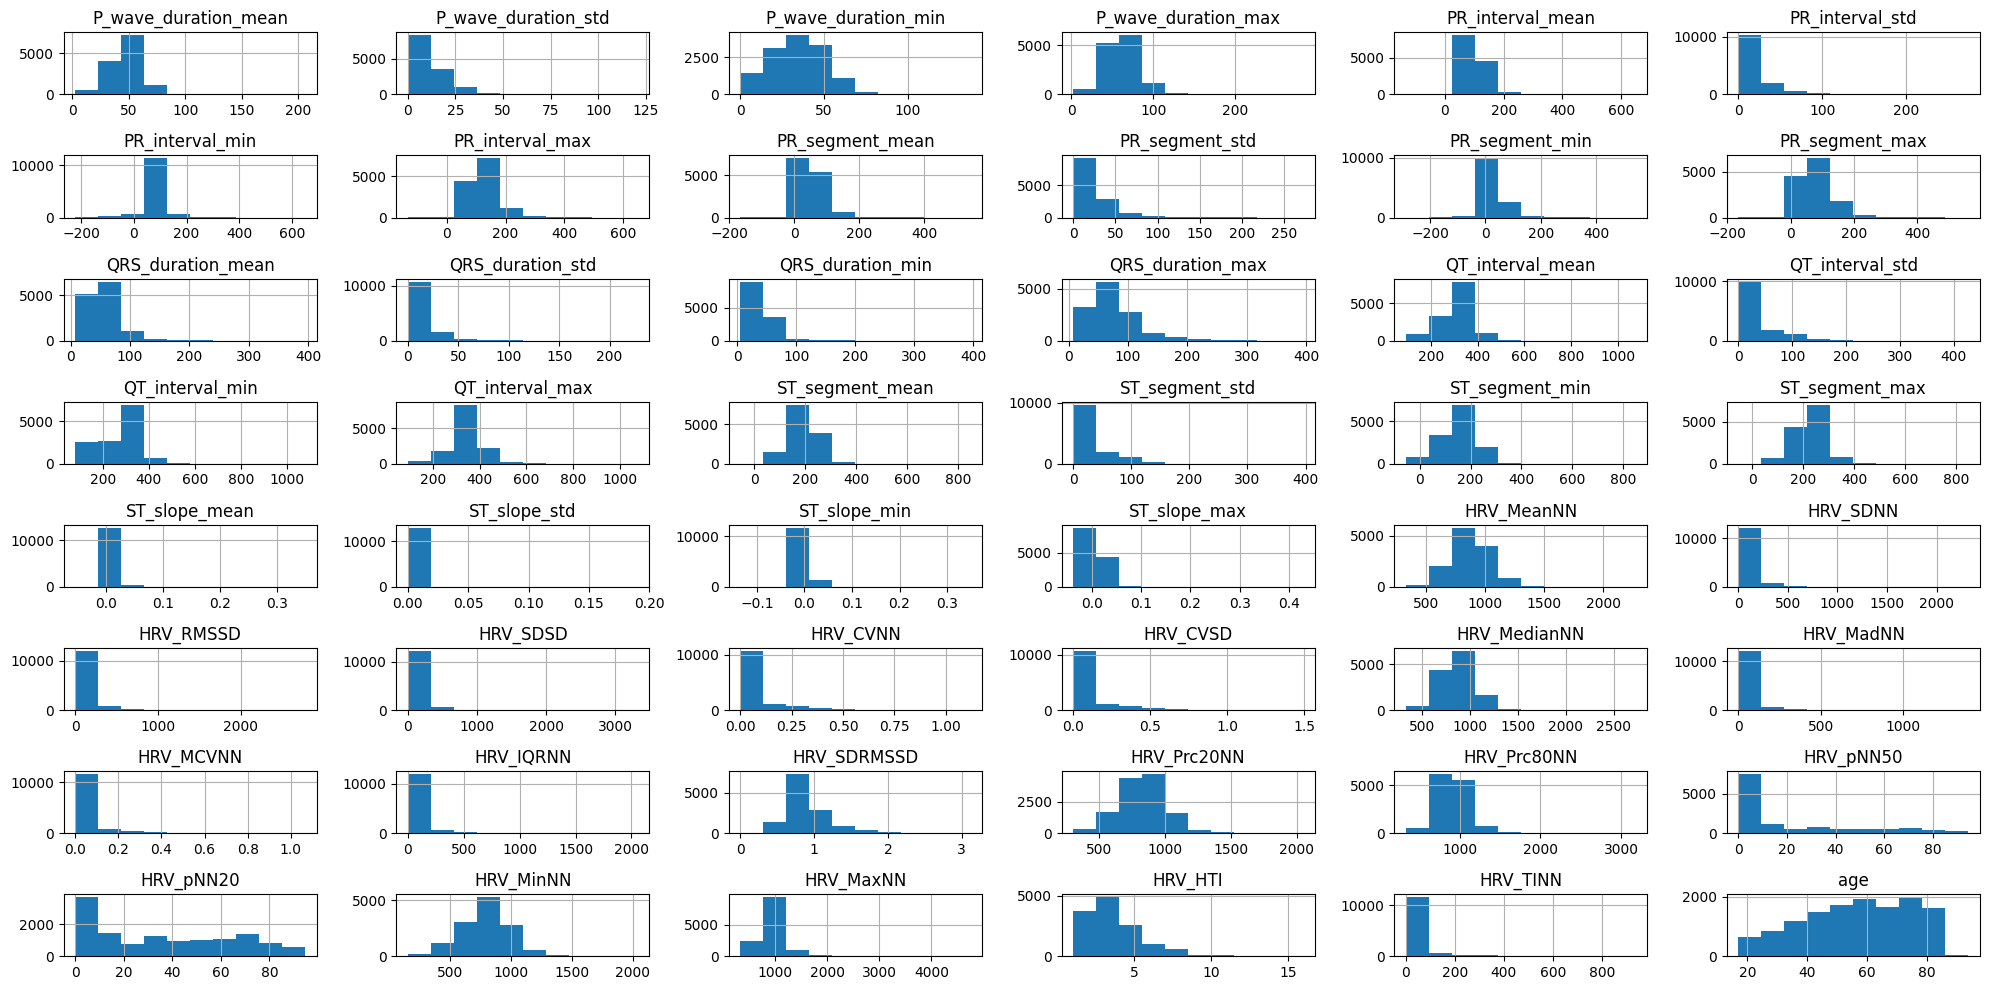

In [38]:
_, axes = plt.subplots(nrows=8, ncols=6, figsize=(20, 10))
for ax, cname in zip(axes.ravel(), num_cols):
    df.hist(cname, ax=ax)
plt.tight_layout()
plt.show()

Plot the distribution of the categorical columns.

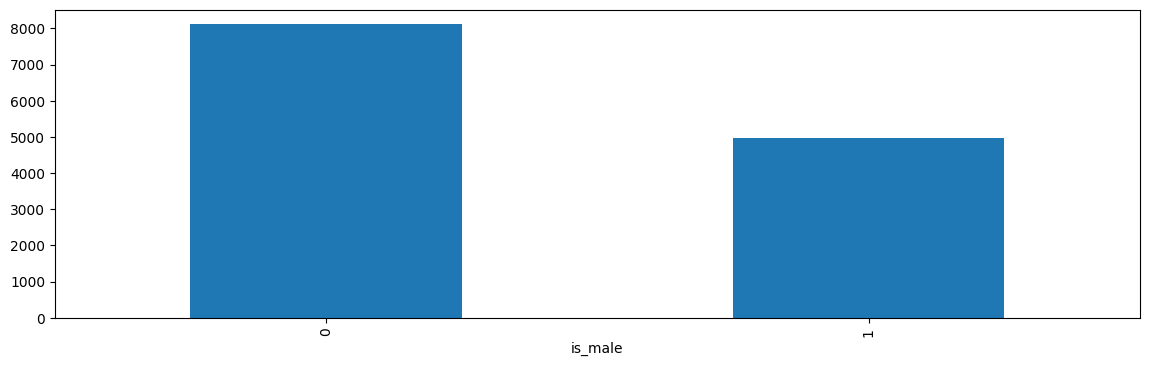

In [39]:
_, axes = plt.subplots(nrows=1, ncols=1, figsize=figsize)
for cname in cat_cols:
    df[cname].value_counts().plot(kind='bar', ax=axes)

Plot the distribution of the target variable.

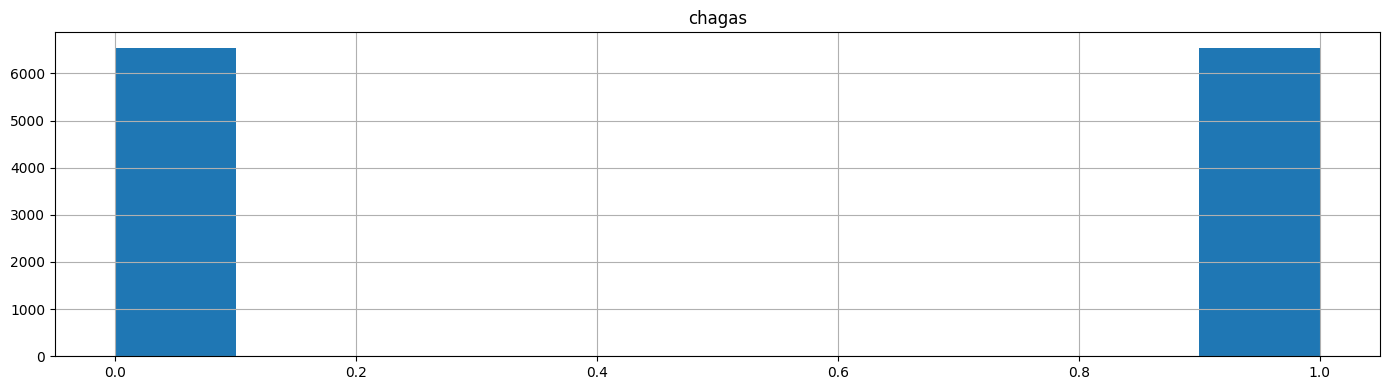

In [40]:
df.hist('chagas', figsize=figsize)
plt.tight_layout()

Plot the distribution of the target variable conditioned on the categorical columns.

In [63]:
df.groupby('is_male')['chagas'].mean()

is_male
0    0.512821
1    0.479477
Name: chagas, dtype: float64

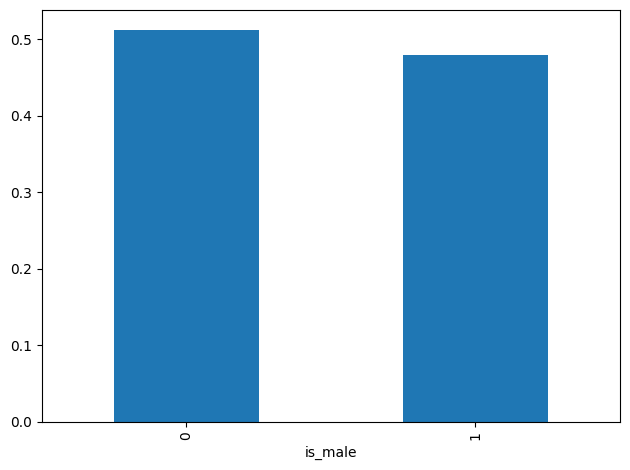

In [64]:
df.groupby('is_male')['chagas'].mean().plot.bar()
plt.tight_layout()

Plot the distribution of the numerical columns conditioned by the target variable.

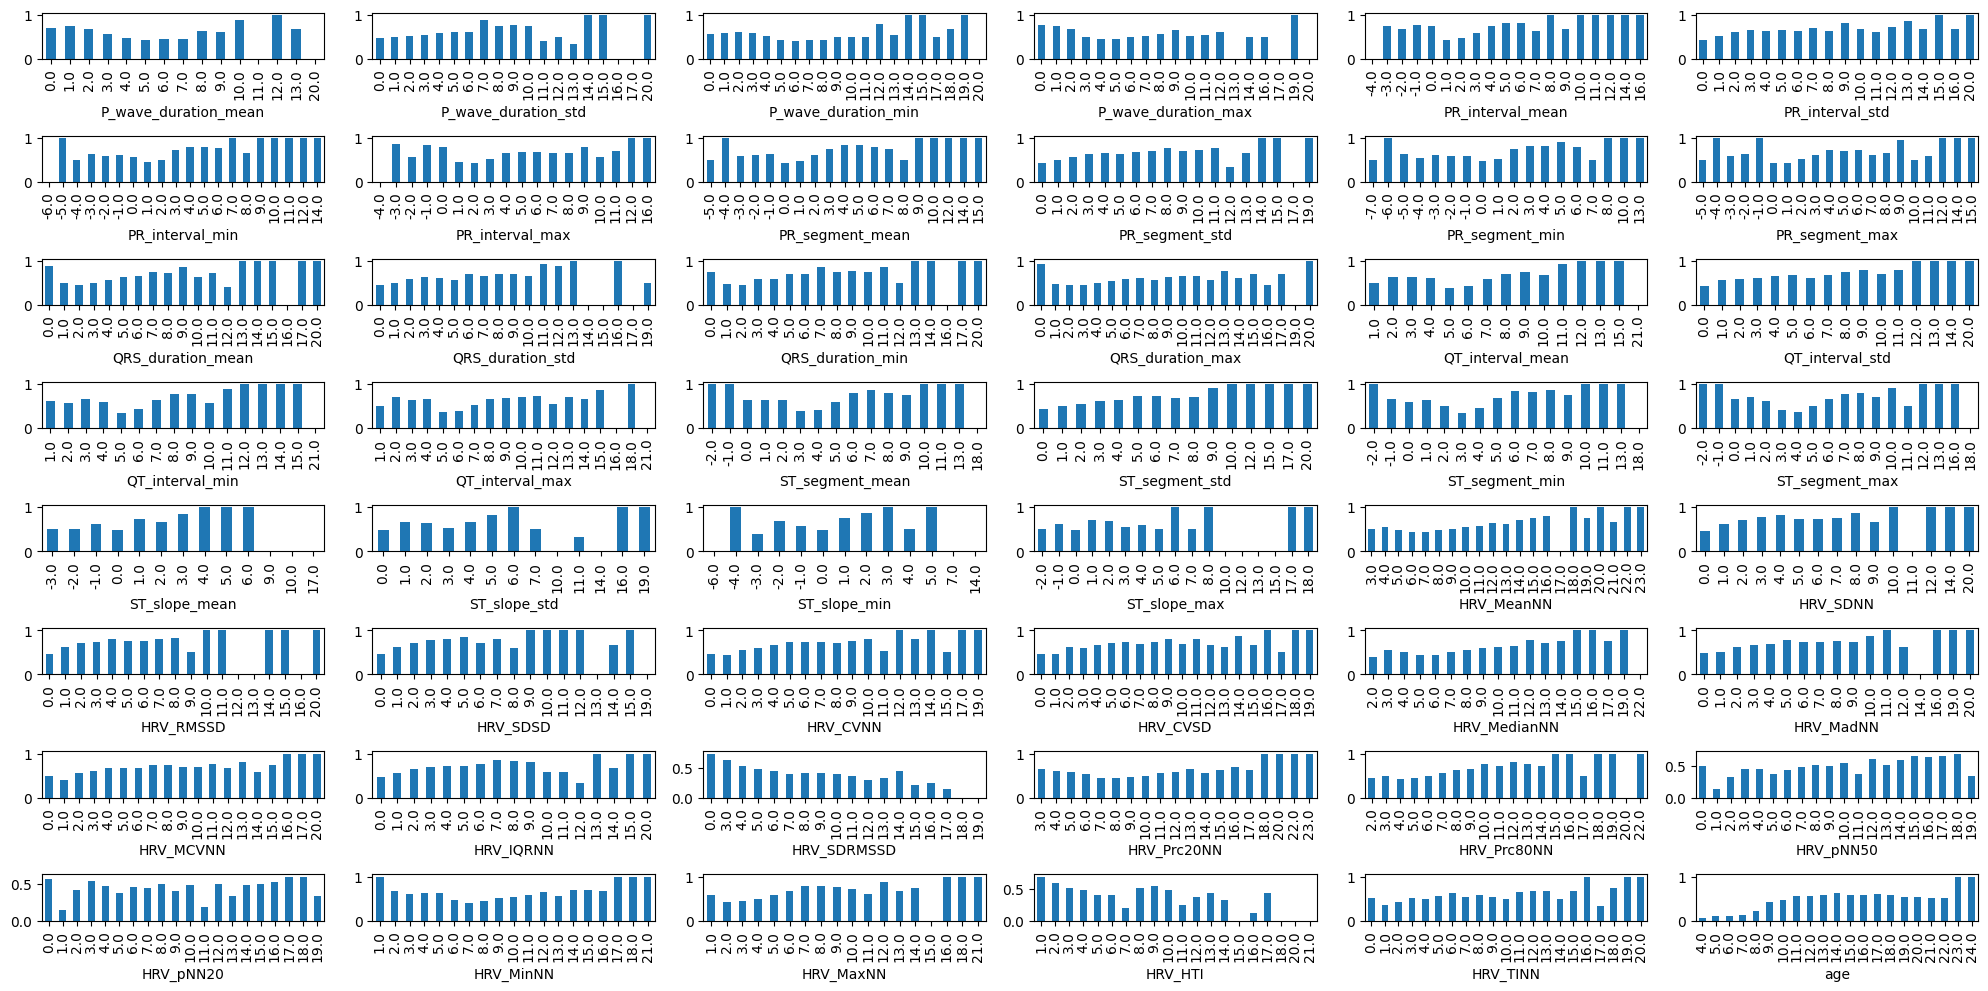

In [65]:
_, axes = plt.subplots(nrows=8, ncols=6, figsize=(20,10))
for ax, cname in zip(axes.ravel(), num_cols):
    bin_size = (df[cname].max() - df[cname].min()) / 20
    df['chagas'].groupby(df[cname] // bin_size).mean().plot.bar(ax=ax)
plt.tight_layout()

Plot the correlation matrix of the numerical columns.

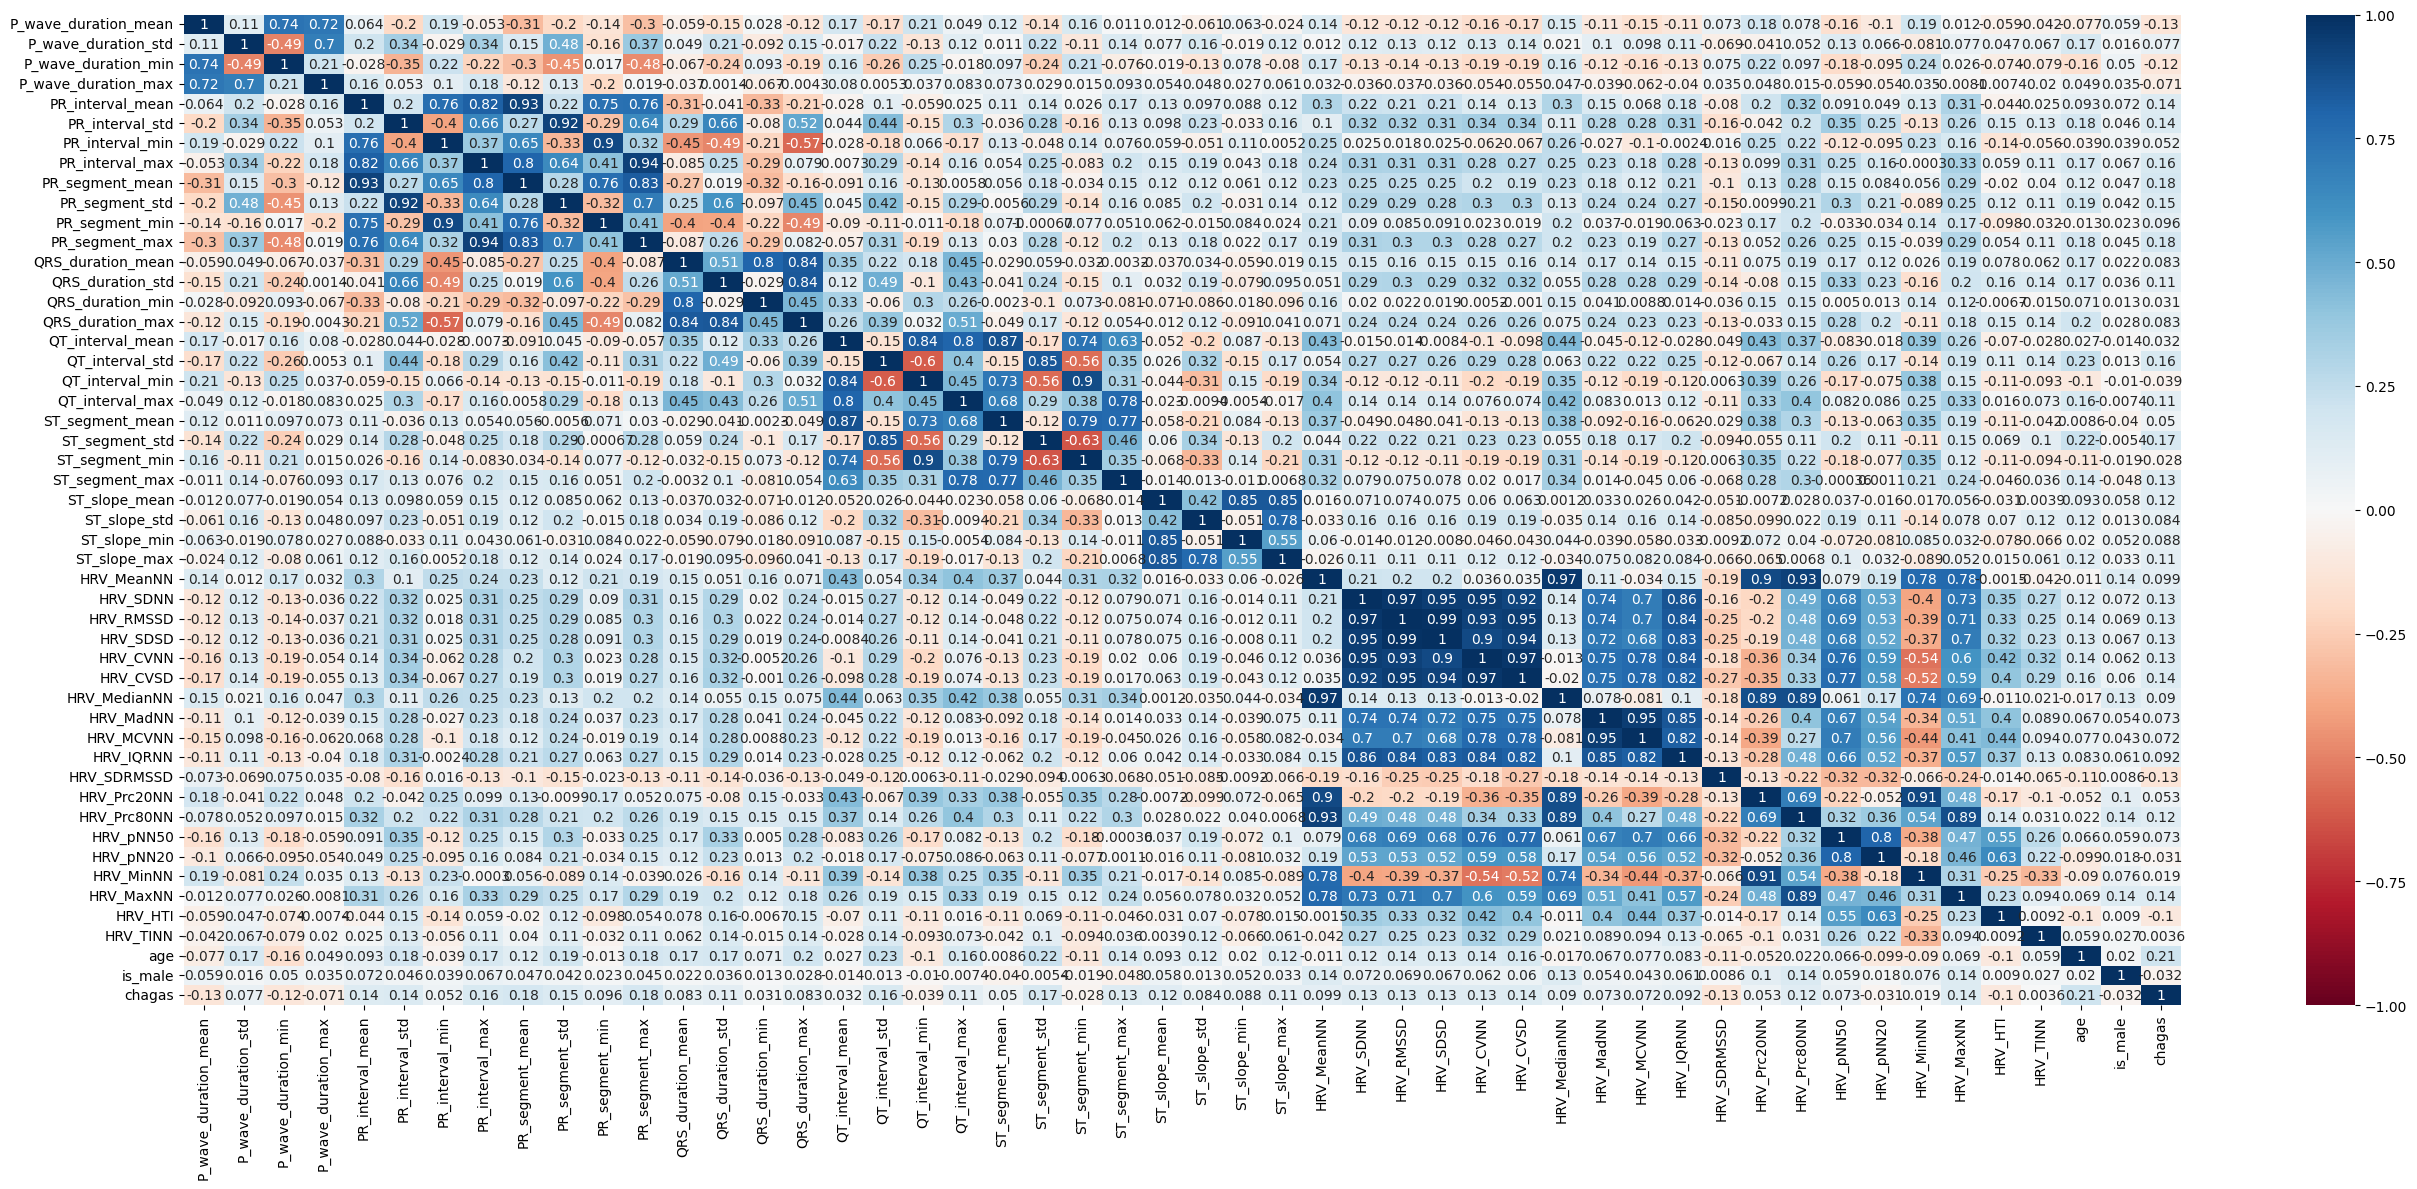

In [66]:
plt.figure(figsize=(27,12))
sn.heatmap(df.corr(method='pearson'), annot=True, vmin=-1, vmax=1, cmap='RdBu')
plt.tight_layout()

Split the data into training and testing sets. Shuffle the data and stratify the target variable.

Apply the StandardScaler to the numerical columns.

In [67]:
X, y = df.drop(columns='chagas', axis=1), df['chagas']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED, stratify=y, shuffle=True)
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

# Logistic Regression

In [68]:
base_est = LogisticRegression(penalty='l1', solver='saga',)
param_grid={'C': 1. / np.linspace(1e-1, 1e4, 100)}
gscv = GridSearchCV(base_est, param_grid=param_grid, scoring='roc_auc')
gscv.fit(X_train, y_train)
lr, lr_params = gscv.best_estimator_, gscv.best_params_

In [71]:
lr_score_cv, lr_score_test = gscv.best_score_, roc_auc_score(y_test, lr.predict_proba(X_test)[:, 1])
print(f'AUC score for C={lr_params["C"]:.2f}: {lr_score_cv:.2f} (cross-validation), {lr_score_test:.2f} (test)')

AUC score for C=10.00: 0.75 (cross-validation), 0.75 (test)


0.6724546172059984
Confusion matrix:
[[0.35727933 0.14252961]
 [0.17462744 0.32556362]]


<Axes: >

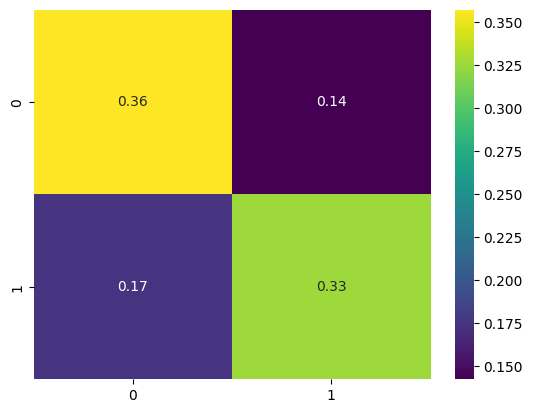

In [75]:
cm = confusion_matrix(y_test, lr.predict(X_test), labels=[0, 1], normalize='all')
print(f1_score(y_test, lr.predict(X_test)))
print(f'Confusion matrix:\n{cm}')
sn.heatmap(cm, annot=True, cmap='viridis')

In [79]:
pd.Series( lr.predict_proba(X_test)[:, 1]).describe()

count    2617.000000
mean        0.499490
std         0.206729
min         0.044380
25%         0.339326
50%         0.480405
75%         0.646283
max         0.997911
dtype: float64

<Axes: >

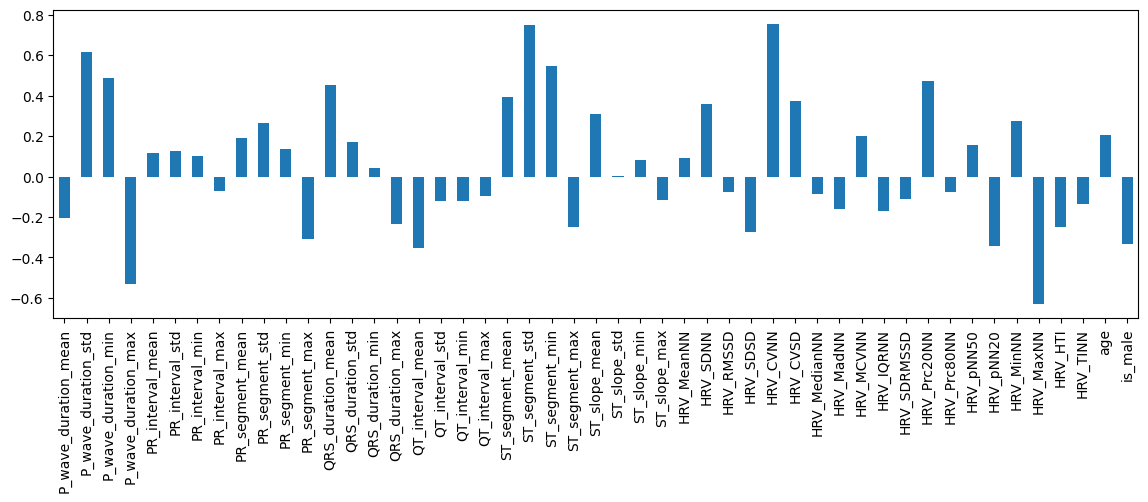

In [80]:
lr_coefs = pd.Series(index=X.columns, data=lr.coef_[0])
lr_coefs.plot(kind='bar', figsize=figsize)

# XGBoost

In [108]:
base_est = xgboost.XGBClassifier(tree_method='hist', importance_type='total_gain')
param_grid={'max_depth': [2, 3, 4], 'n_estimators': list(range(20, 41, 5)), 'reg_lambda': np.linspace(0, 500, 6)}
gscv = GridSearchCV(base_est, param_grid=param_grid)
gscv.fit(X_train, y_train)
xbm, xbm_params = gscv.best_estimator_, gscv.best_params_

0.7144970414201184
Confusion matrix:
[[0.33588078 0.16392816]
 [0.13106611 0.36912495]]


<Axes: >

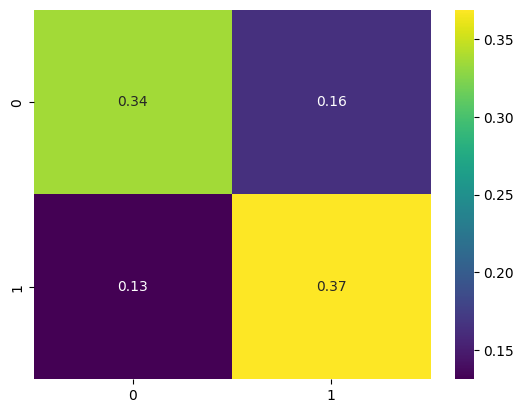

In [109]:
cm = confusion_matrix(y_test, xbm.predict(X_test), labels=[0, 1], normalize='all')
print(f1_score(y_test, xbm.predict(X_test)))
print(f'Confusion matrix:\n{cm}')
sn.heatmap(cm, annot=True, cmap='viridis')

<Axes: >

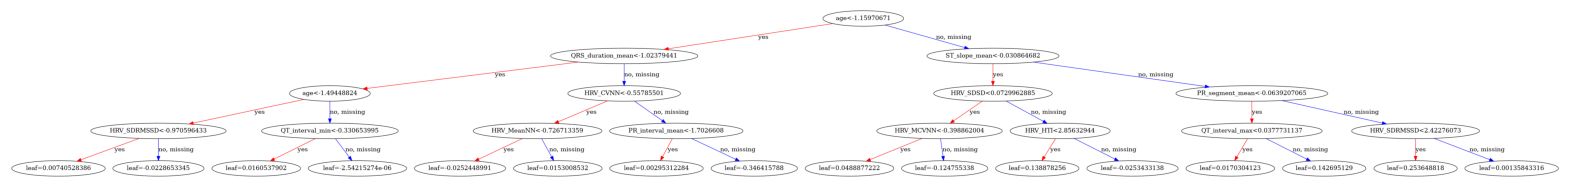

In [110]:
plt.figure(figsize=(20, 20))
xgboost.plot_tree(xbm, ax=plt.gca(), num_trees=0)

In [111]:
xbm_score_cv, xbm_score_test = gscv.best_score_, roc_auc_score(y_test, xbm.predict(X_test))
print(f'AUC score for {xbm_params}: {xbm_score_cv:.2f} (cross-val.), {xbm_score_test:.2f} (test)')

AUC score for {'max_depth': 4, 'n_estimators': 40, 'reg_lambda': np.float64(100.0)}: 0.71 (cross-val.), 0.70 (test)


<Axes: >

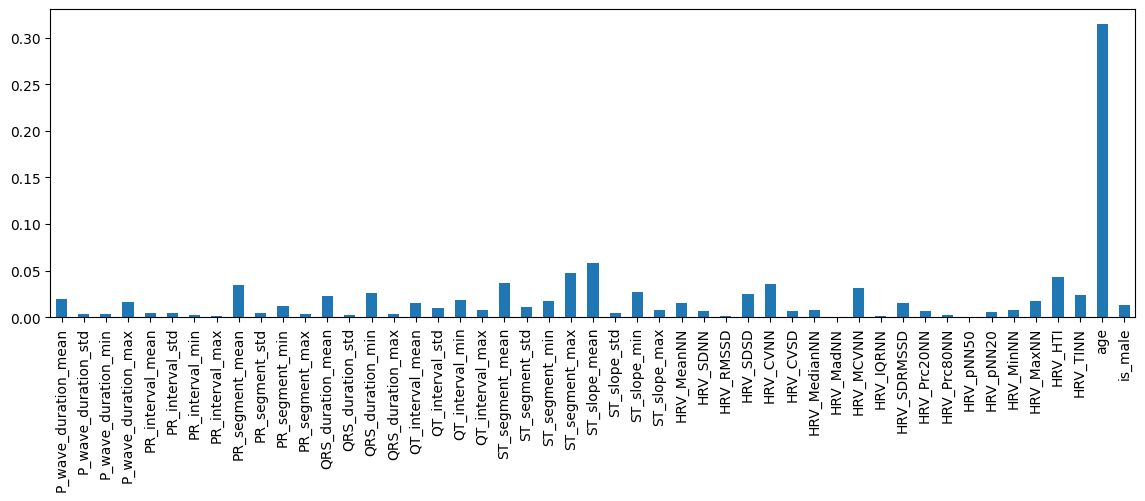

In [112]:
xbm_imp = pd.Series(index=X.columns, data=xbm.feature_importances_)
xbm_imp.plot(kind='bar', figsize=figsize)

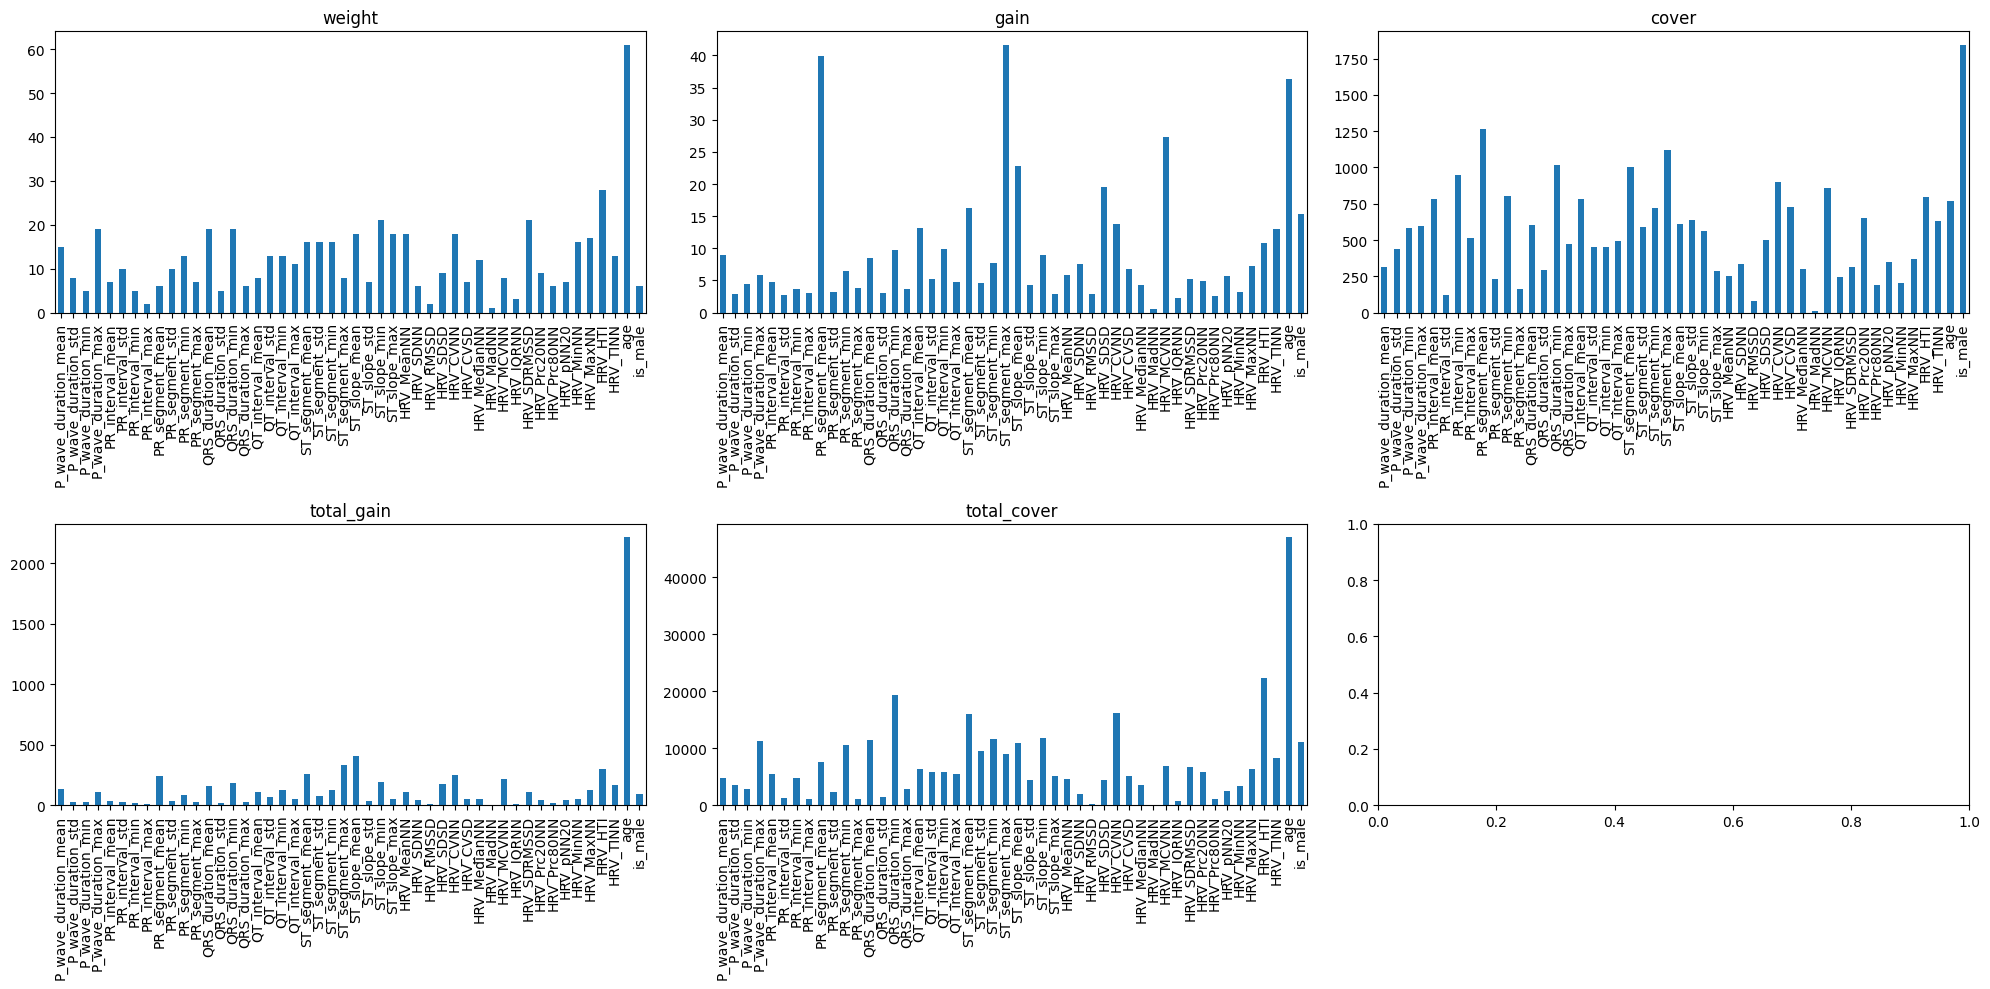

In [113]:
_, axes = plt.subplots(nrows=2, ncols=3, figsize=(20, 10))
for ax, imp_type in zip(axes.ravel(), ['weight', 'gain', 'cover', 'total_gain', 'total_cover']):
    pd.Series(xbm.get_booster().get_score(importance_type=imp_type)).plot.bar(ax=ax, title=imp_type)
plt.tight_layout()

# Permutation Importance

2025-01-30 17:10:37.888140: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1738253438.055347   78341 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1738253438.098369   78341 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-01-30 17:10:38.461767: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


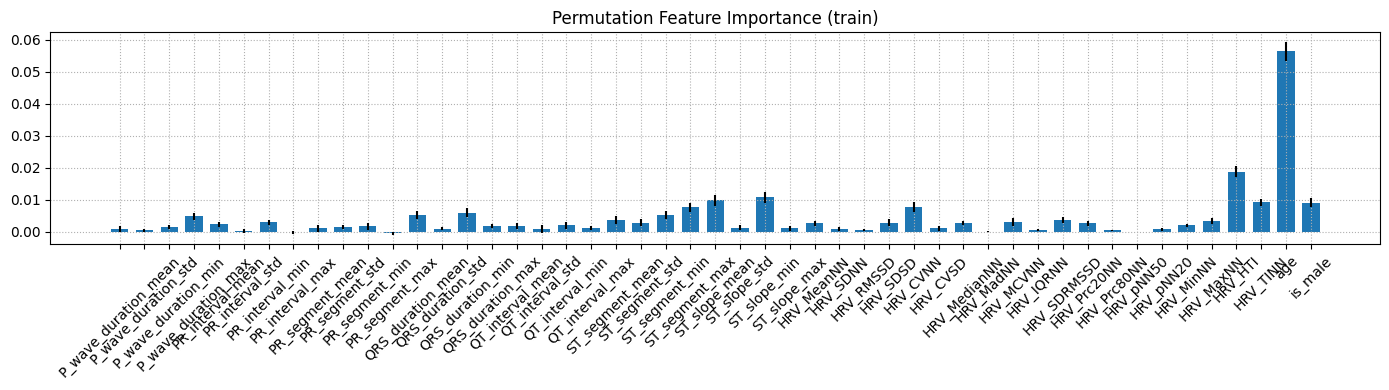

In [96]:
import util

r_train = permutation_importance(xbm, X_train, y_train, n_repeats=30, random_state=SEED)
xbm_p_imp = pd.Series(index=X.columns, data=r_train.importances_mean)
util.plot_bars(xbm_p_imp, figsize=figsize, std=r_train.importances_std, title='Permutation Feature Importance (train)')

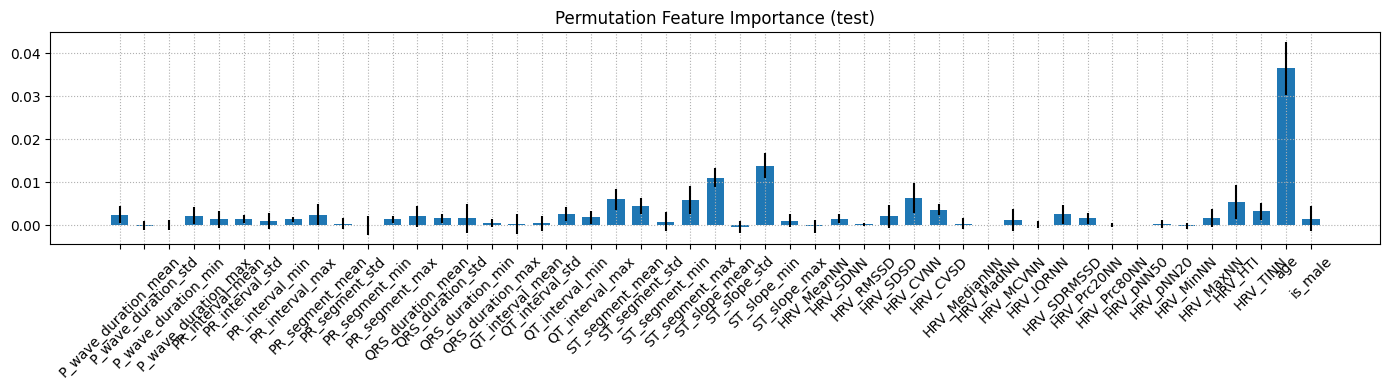

In [97]:
r_test = permutation_importance(xbm, X_test, y_test, n_repeats=30, random_state=SEED)
xbm_p_imp = pd.Series(index=X.columns, data=r_test.importances_mean)
util.plot_bars(xbm_p_imp, figsize=figsize, std=r_test.importances_std, title='Permutation Feature Importance (test)')

# SHAP Values

In [ ]:
f = lambda x: xbm.predict_proba(x)[:,1]
explainer = shap.KernelExplainer(f, shap.sample(X_train, 100), link='logit', seed=SEED)
shap_values = explainer(X_test)

# BorutaPy Feature Selection

In [100]:
bfs = BorutaPy(xbm, n_estimators='auto', max_iter=100, verbose=0, random_state=SEED)
bfs.fit(X=X, y=y)

KeyboardInterrupt: 

In [250]:
print('Confirmed important:', X.columns[bfs.ranking_ == 1].values)
print('Uncomfirmed:', X.columns[bfs.ranking_ == 2].values)
print('Confirmed unimportant:', X.columns[bfs.ranking_ > 2].values)

Confirmed important: ['P_wave_duration_mean' 'P_wave_duration_max' 'PR_interval_std'
 'PR_segment_mean' 'PR_segment_max' 'QRS_duration_min' 'QT_interval_mean'
 'QT_interval_std' 'QT_interval_min' 'QT_interval_max' 'ST_segment_mean'
 'ST_segment_std' 'ST_segment_max' 'ST_slope_mean' 'ST_slope_min'
 'ST_slope_max']
Uncomfirmed: ['P_wave_duration_std' 'ST_segment_min' 'ST_slope_std']
Confirmed unimportant: ['P_wave_duration_min' 'PR_interval_mean' 'PR_interval_min'
 'PR_interval_max' 'PR_segment_std' 'PR_segment_min' 'QRS_duration_mean'
 'QRS_duration_std' 'QRS_duration_max' 'is_male']
